# LiteCue-Net Training Monitor

**功能：**
实时读取 `logs/` 目录下的训练日志文件，解析并可视化 Loss 曲线和 AUC/Accuracy 趋势图。

**使用方法：**
1. 在终端运行 `python main.py` 启动训练。
2. 运行此 Notebook，它会自动找到最新的日志文件并开始刷新图表。

In [1]:
import os
import sys
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (18, 6)

# 项目根目录设置
project_root = os.path.abspath('..')
LOG_DIR = os.path.join(project_root, 'logs')

print(f"Monitoring logs in: {LOG_DIR}")

Monitoring logs in: d:\01_Lab\Project\LiteCue-Net\logs


### 1. 日志解析核心逻辑
定义两个正则模式来提取 `Trainer` 输出的信息：
1. **Training Step**: `Epoch: [1][10/314] ... Loss 0.6931 ...`
2. **Validation Epoch**: `Epoch [1] Validation Result: Loss: 0.5000 | AUC: 85.00% | Acc: 80.00%`

In [2]:
def get_latest_log_file(log_dir):
    """找到 logs 目录下最新的 .log 文件"""
    if not os.path.exists(log_dir):
        return None
    files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if f.endswith('.log')]
    if not files:
        return None
    # 按修改时间排序，取最新的
    latest_file = max(files, key=os.path.getmtime)
    return latest_file

def parse_log(file_path):
    """解析日志文件，返回 Train 和 Val 的 DataFrame"""
    train_data = []
    val_data = []
    
    # 正则表达式 (根据 trainer.py 的输出格式定制)
    # Train Pattern: Epoch: [1][10/314] Time 0.1s Data 0.0s Loss 0.6931 (0.6900) Acc 50.00 (51.00)
    # 我们提取 Loss 的当前值 (不是平均值)
    train_pattern = re.compile(r"Epoch: \[(\d+)\]\[(\d+)/\d+\] .*? Loss (\d+\.\d+) .*? Acc (\d+\.\d+)")
    
    # Val Pattern: Epoch [1] Validation Result: Loss: 0.5231 | AUC: 85.12% | Acc: 82.10%
    val_pattern = re.compile(r"Epoch \[(\d+)\] Validation Result: Loss: (\d+\.\d+) \| AUC: (\d+\.\d+)% \| Acc: (\d+\.\d+)%")

    # 尝试多种编码方式读取文件
    encodings = ['utf-8', 'gbk', 'gb2312', 'latin-1', 'cp1252']
    file_content = None
    
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding, errors='replace') as f:
                file_content = f.readlines()
            break
        except (UnicodeDecodeError, UnicodeError):
            continue
    
    if file_content is None:
        # 如果所有编码都失败，使用 errors='replace' 强制读取
        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            file_content = f.readlines()
    
    for line in file_content:
        # 匹配训练行
        t_match = train_pattern.search(line)
        if t_match:
            epoch = int(t_match.group(1))
            step = int(t_match.group(2))
            loss = float(t_match.group(3))
            acc = float(t_match.group(4))
            
            # 为了画图方便，我们可以构造一个全局 step 计数，或者简单用 epoch + step/total_steps
            # 这里简单存 epoch 和 step
            train_data.append({
                'epoch': epoch,
                'step': step,
                'loss': loss,
                'batch_acc': acc
            })
            continue

        # 匹配验证行
        v_match = val_pattern.search(line)
        if v_match:
            epoch = int(v_match.group(1))
            val_loss = float(v_match.group(2))
            auc = float(v_match.group(3))
            acc = float(v_match.group(4))
            
            val_data.append({
                'epoch': epoch,
                'val_loss': val_loss,
                'auc': auc,
                'acc': acc
            })
                
    return pd.DataFrame(train_data), pd.DataFrame(val_data)

### 2. 可视化函数

In [3]:
def plot_monitoring(train_df, val_df, log_filename):
    """绘制三张图表: Train Loss, Val Metrics, Val Loss"""
    if len(train_df) == 0 and len(val_df) == 0:
        print("Waiting for data...")
        return

    clear_output(wait=True) # 清除上一次的图表，实现动画效果
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Training Monitor: {log_filename}", fontsize=16)
    
    # --- 图 1: Training Loss (Step-level) ---
    if len(train_df) > 0:
        # 为了让曲线平滑，我们可以计算滑动平均
        train_df['loss_smooth'] = train_df['loss'].rolling(window=20, min_periods=1).mean()
        
        # 构建一个连续的 x 轴
        # 简单处理：直接用索引作为 steps
        axes[0].plot(train_df.index, train_df['loss'], alpha=0.3, color='gray', label='Raw Loss')
        axes[0].plot(train_df.index, train_df['loss_smooth'], color='blue', linewidth=2, label='Smoothed (MA20)')
        axes[0].set_title("Training Loss (Per Batch)")
        axes[0].set_xlabel("Total Steps")
        axes[0].set_ylabel("Focal Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- 图 2: Validation Metrics (AUC & Acc) ---
    if len(val_df) > 0:
        axes[1].plot(val_df['epoch'], val_df['auc'], 'o-', color='red', label='AUC (%)', linewidth=2)
        axes[1].plot(val_df['epoch'], val_df['acc'], 's--', color='green', label='Accuracy (%)', linewidth=1.5)
        
        # 标注最高点
        if len(val_df) > 0:
            best_auc = val_df['auc'].max()
            best_epoch = val_df.loc[val_df['auc'].idxmax(), 'epoch']
            axes[1].annotate(f'Best: {best_auc:.2f}%', 
                             xy=(best_epoch, best_auc), 
                             xytext=(best_epoch, best_auc-5),
                             arrowprops=dict(facecolor='black', shrink=0.05))

        axes[1].set_title("Validation Metrics (Per Epoch)")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Percentage (%)")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
    # --- 图 3: Validation Loss Trend ---
    if len(val_df) > 0:
        axes[2].plot(val_df['epoch'], val_df['val_loss'], 'd-', color='purple', label='Val Loss')
        axes[2].set_title("Validation Loss (Per Epoch)")
        axes[2].set_xlabel("Epoch")
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    
    # 打印最新状态
    if len(train_df) > 0:
        print(f"Last Train Loss: {train_df.iloc[-1]['loss']:.4f} | Batch Acc: {train_df.iloc[-1]['batch_acc']:.2f}%")
    if len(val_df) > 0:
        latest = val_df.iloc[-1]
        print(f"Last Val Result (Epoch {int(latest['epoch'])}): AUC={latest['auc']:.2f}% | Acc={latest['acc']:.2f}%")

### 3. 启动实时监控循环

运行下面代码块，会每隔 10 秒刷新一个图表

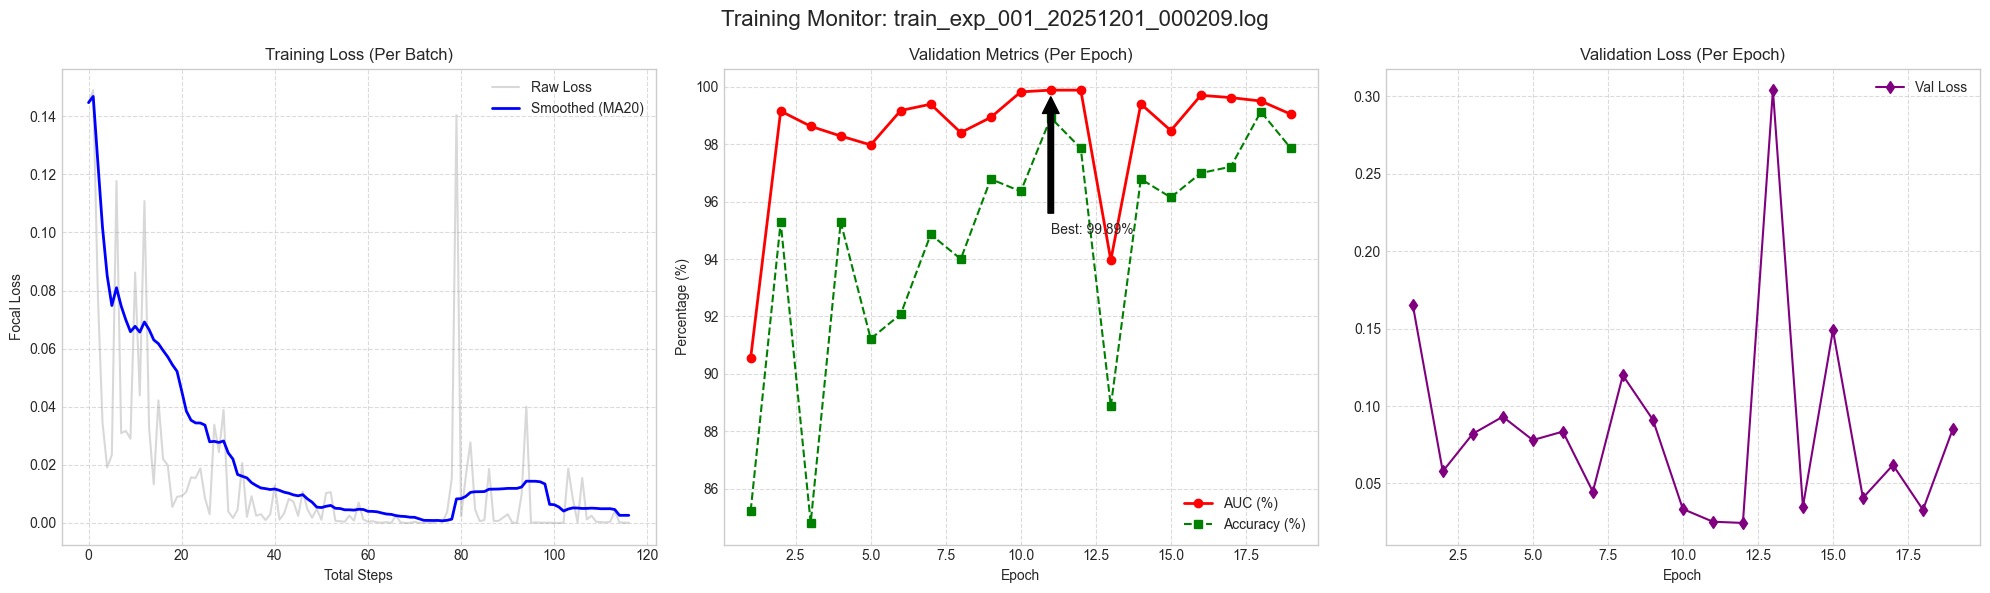

Last Train Loss: 0.0001 | Batch Acc: 100.00%
Last Val Result (Epoch 19): AUC=99.05% | Acc=97.86%

Monitor stopped by user.


In [4]:
try:
    print("Searching for logs...")
    target_log = get_latest_log_file(LOG_DIR)
    
    if not target_log:
        print("No log files found. Please start training first!")
    else:
        print(f"Found log file: {os.path.basename(target_log)}")
        print("Starting real-time monitor (Interrupt kernel to stop)...")
        
        while True:
            # 1. 重新检测最新的日志文件 (防止用户重新开启了新训练)
            current_latest = get_latest_log_file(LOG_DIR)
            if current_latest != target_log:
                print(f"New training session detected: {os.path.basename(current_latest)}")
                target_log = current_latest
                time.sleep(2) # 等待文件写入一点内容
            
            # 2. 解析
            train_df, val_df = parse_log(target_log)
            
            # 3. 绘图
            plot_monitoring(train_df, val_df, os.path.basename(target_log))
            
            # 4. 休眠
            time.sleep(10) # 每10秒刷新一次

except KeyboardInterrupt:
    print("\nMonitor stopped by user.")